MAXVIT - STAGE 3
Feature map: 14 x 14
Window/Grid size: 7 x 7
Thông tin đầu vào:
- Stage được chọn: 3
- Kích thước feature map: 14 x 14
- Kích thước window/grid: 7 x 7

[BLOCK-SA]
Số nhóm: 4
Số token mỗi nhóm: 49

[GRID-SA]
Số nhóm: 49
Số token mỗi nhóm: 4


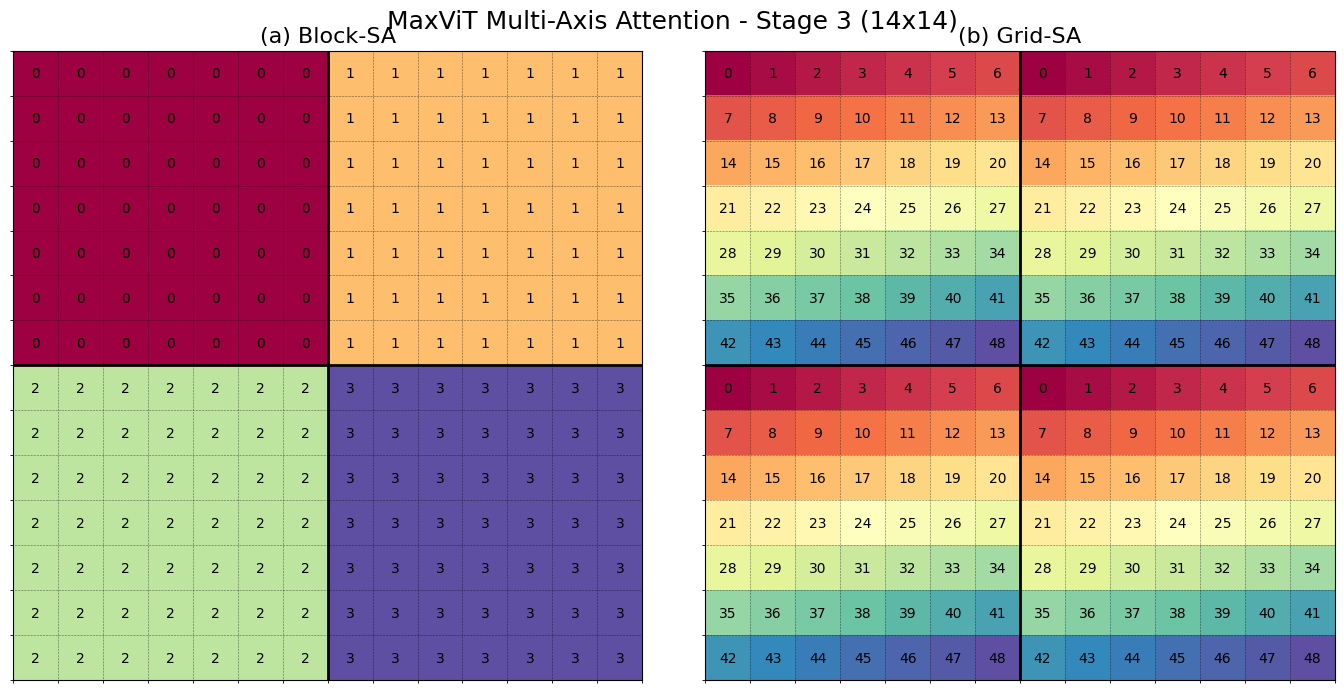


Kiểm tra kết quả:
- Kích thước lưới Block-SA đúng: (14, 14)
- Kích thước lưới Grid-SA đúng: (14, 14)
- Số nhóm Block-SA đúng: 4
- Số nhóm Grid-SA đúng: 49
Code chạy đúng.


In [6]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: TRỰC QUAN HÓA BLOCK-SA VÀ GRID-SA TRONG MAXVIT
# Chương/Mục liên quan: Chương 7 - Vision Transformer và các biến thể
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách MaxViT chia token thành các nhóm attention theo hai cơ chế Block-SA và Grid-SA.
# - Giúp người học quan sát trực tiếp sự khác nhau giữa chia nhóm theo cửa sổ cục bộ và chia nhóm theo vị trí tương đối trong cửa sổ.
# - Liên hệ phần code với cơ chế multi-axis attention trong MaxViT.

# Sau khi chạy code, người học cần:
# 1. Hiểu cách feature map được chia thành các nhóm token.
# 2. Phân biệt được Block-SA và Grid-SA trên cùng một kích thước feature map.
# 3. Biết thay đổi stage để quan sát ảnh hưởng của kích thước lưới token.

# Input:
# - Dữ liệu đầu vào: không dùng ảnh, chỉ dùng lưới token mô phỏng feature map của MaxViT.
# - Tham số đầu vào: STAGE = 1, 2, 3 hoặc 4.
# - Kích thước feature map tương ứng:
#   Stage 1 -> 56 x 56
#   Stage 2 -> 28 x 28
#   Stage 3 -> 14 x 14
#   Stage 4 -> 7 x 7
# - Window/Grid size: 7 x 7.

# Output:
# - Lưới nhóm token của Block-SA.
# - Lưới nhóm token của Grid-SA.
# - Thống kê số nhóm attention và số token trong mỗi nhóm.
# - Hình trực quan hóa hai cơ chế chia nhóm token.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2. TẠO DỮ LIỆU ĐẦU VÀO
# ============================================================

STAGE = 3   # Đổi thành 1, 2, 3 hoặc 4 để chọn stage của MaxViT

stage_to_size = {
    1: 56,
    2: 28,
    3: 14,
    4: 7
}

H = W = stage_to_size[STAGE]

WINDOW_SIZE = 7

print("=" * 60)
print(f"MAXVIT - STAGE {STAGE}")
print(f"Feature map: {H} x {W}")
print(f"Window/Grid size: {WINDOW_SIZE} x {WINDOW_SIZE}")
print("=" * 60)

# ============================================================
# 3. HIỂN THỊ THÔNG TIN ĐẦU VÀO
# ============================================================

print("Thông tin đầu vào:")
print(f"- Stage được chọn: {STAGE}")
print(f"- Kích thước feature map: {H} x {W}")
print(f"- Kích thước window/grid: {WINDOW_SIZE} x {WINDOW_SIZE}")

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# ------------------------------------------------------------
# 4.1. Block-SA
# ------------------------------------------------------------

block_sa = np.zeros((H, W), dtype=int)

num_block_rows = H // WINDOW_SIZE
num_block_cols = W // WINDOW_SIZE

for i in range(H):
    for j in range(W):

        # Xác định block chứa token tại vị trí (i, j)
        br = i // WINDOW_SIZE
        bc = j // WINDOW_SIZE

        # Dòng này tương ứng với phép gán nhóm attention theo block cục bộ
        group_id = br * num_block_cols + bc

        block_sa[i, j] = group_id

# ------------------------------------------------------------
# 4.2. Grid-SA
# ------------------------------------------------------------

grid_sa = np.zeros((H, W), dtype=int)

for i in range(H):
    for j in range(W):

        # Xác định vị trí tương đối của token trong window 7 x 7
        local_i = i % WINDOW_SIZE
        local_j = j % WINDOW_SIZE

        # Dòng này tương ứng với phép gán nhóm attention theo vị trí tương đối trong grid
        group_id = local_i * WINDOW_SIZE + local_j

        grid_sa[i, j] = group_id

# ------------------------------------------------------------
# 4.3. Thống kê
# ------------------------------------------------------------

print("\n[BLOCK-SA]")
print("Số nhóm:",
      (H // WINDOW_SIZE) * (W // WINDOW_SIZE))

print("Số token mỗi nhóm:",
      WINDOW_SIZE * WINDOW_SIZE)

print("\n[GRID-SA]")
print("Số nhóm:",
      WINDOW_SIZE * WINDOW_SIZE)

print("Số token mỗi nhóm:",
      (H // WINDOW_SIZE) * (W // WINDOW_SIZE))

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

def draw_attention_groups(ax,
                          grid,
                          title,
                          window_size=7):

    n_groups = grid.max() + 1

    ax.imshow(
        grid,
        cmap="Spectral",
        vmin=0,
        vmax=n_groups - 1
    )

    H, W = grid.shape

    # Vẽ lưới token
    ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, H, 1), minor=True)

    ax.grid(
        which="minor",
        color="black",
        linestyle=":",
        linewidth=0.4
    )

    # Vẽ đường chia window 7 x 7
    for x in range(window_size, W, window_size):
        ax.axvline(x - 0.5,
                   color="black",
                   linewidth=2)

    for y in range(window_size, H, window_size):
        ax.axhline(y - 0.5,
                   color="black",
                   linewidth=2)

    # In số nhóm nếu feature map không quá lớn
    if H <= 28:

        fontsize = 10 if H <= 14 else 6

        for i in range(H):
            for j in range(W):

                ax.text(
                    j,
                    i,
                    str(grid[i, j]),
                    ha="center",
                    va="center",
                    fontsize=fontsize,
                    color="black"
                )

    ax.set_title(title, fontsize=16)

    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

draw_attention_groups(
    axes[0],
    block_sa,
    "(a) Block-SA"
)

draw_attention_groups(
    axes[1],
    grid_sa,
    "(b) Grid-SA"
)

plt.suptitle(
    f"MaxViT Multi-Axis Attention - Stage {STAGE} ({H}x{W})",
    fontsize=18
)

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

assert block_sa.shape == (H, W)
assert grid_sa.shape == (H, W)

assert block_sa.min() == 0
assert grid_sa.min() == 0

assert block_sa.max() + 1 == (H // WINDOW_SIZE) * (W // WINDOW_SIZE)
assert grid_sa.max() + 1 == WINDOW_SIZE * WINDOW_SIZE

print("\nKiểm tra kết quả:")
print("- Kích thước lưới Block-SA đúng:", block_sa.shape)
print("- Kích thước lưới Grid-SA đúng:", grid_sa.shape)
print("- Số nhóm Block-SA đúng:", block_sa.max() + 1)
print("- Số nhóm Grid-SA đúng:", grid_sa.max() + 1)
print("Code chạy đúng.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Gợi ý 1:
# - Đổi STAGE = 1, 2, 3 hoặc 4 để quan sát ảnh hưởng của kích thước feature map.

# Gợi ý 2:
# - So sánh số token trong mỗi nhóm giữa Block-SA và Grid-SA khi STAGE thay đổi.

# Gợi ý 3:
# - Giữ WINDOW_SIZE = 7 để đúng với ví dụ MaxViT thông dụng;
#   có thể thử WINDOW_SIZE khác nếu muốn quan sát nguyên lý chia nhóm tổng quát.